In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- QUESTION 1: Reconstruct the final 2024-25 Premier League table ---
df_table = pd.read_csv(r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\league_table_24_25.csv.csv")

df_table.head(20)

,LeaguePosition,Team,Points,GoalsScored,GoalsConceded,GoalDifference,ScoringRank
0,1,Liverpool,84,86,41,45,1
1,2,Arsenal,74,69,34,35,3
2,3,Man City,71,72,44,28,2
3,4,Chelsea,69,64,43,21,7
4,5,Newcastle,66,68,47,21,4
5,6,Aston Villa,66,58,51,7,9
6,7,Nott'm Forest,65,58,46,12,9
7,8,Brighton,61,66,59,7,5
8,9,Bournemouth,56,58,46,12,9
9,10,Brentford,56,66,57,9,5


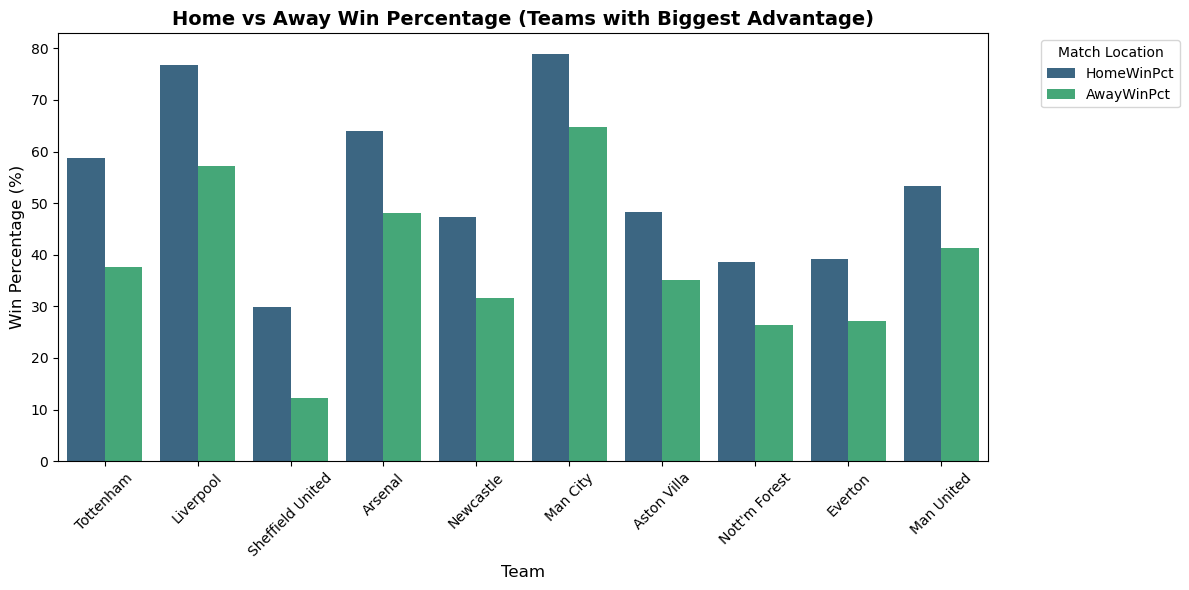

In [5]:
# --- QUESTION 2: Quantifying Home Advantage ---

# Hardcoded with the .csv.csv extension to match the Windows file system
file_path = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\home_advantage_gap.csv.csv"
df_home_adv = pd.read_csv(file_path)

# Grab just the top 10 teams with the biggest advantage so the chart isn't crowded
df_top10 = df_home_adv.head(10)

# Reshape the data so Seaborn can put Home and Away bars side-by-side
df_melted = df_top10.melt(id_vars='Team', 
                          value_vars=['HomeWinPct', 'AwayWinPct'], 
                          var_name='Location', 
                          value_name='Win_Percentage')

# Set up the canvas and draw the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Team', y='Win_Percentage', hue='Location', palette='viridis')

# Format it to look professional
plt.title('Home vs Away Win Percentage (Teams with Biggest Advantage)', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)
plt.xticks(rotation=45) 
plt.legend(title='Match Location', bbox_to_anchor=(1.05, 1), loc='upper left')

# Render the chart
plt.tight_layout()
plt.show()

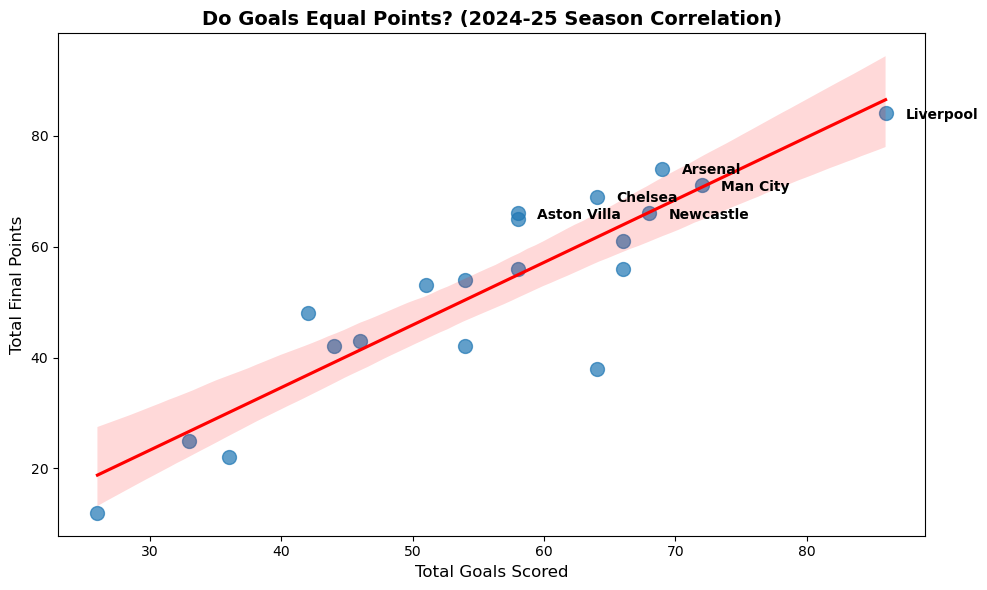

In [6]:
# --- QUESTION 3: Top Scorers vs. Final Points Correlation ---

# 1. We reuse the file we already know works perfectly
file_path_3 = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\league_table_24_25.csv.csv"
df_champ = pd.read_csv(file_path_3)

# 2. Set up the canvas
plt.figure(figsize=(10, 6))

# 3. Draw a scatter plot with a correlation trendline (regplot)
sns.regplot(data=df_champ, x='GoalsScored', y='Points', 
            scatter_kws={'s': 100, 'alpha': 0.7}, 
            line_kws={'color': 'red'})

# 4. Add text labels to the Top 6 teams so we can see who the dots represent
for i in range(6):
    plt.text(df_champ['GoalsScored'][i] + 1.5, df_champ['Points'][i] - 1, 
             df_champ['Team'][i], fontsize=10, fontweight='bold')

# 5. Format it cleanly
plt.title('Do Goals Equal Points? (2024-25 Season Correlation)', fontsize=14, fontweight='bold')
plt.xlabel('Total Goals Scored', fontsize=12)
plt.ylabel('Total Final Points', fontsize=12)

# 6. Render
plt.tight_layout()
plt.show()

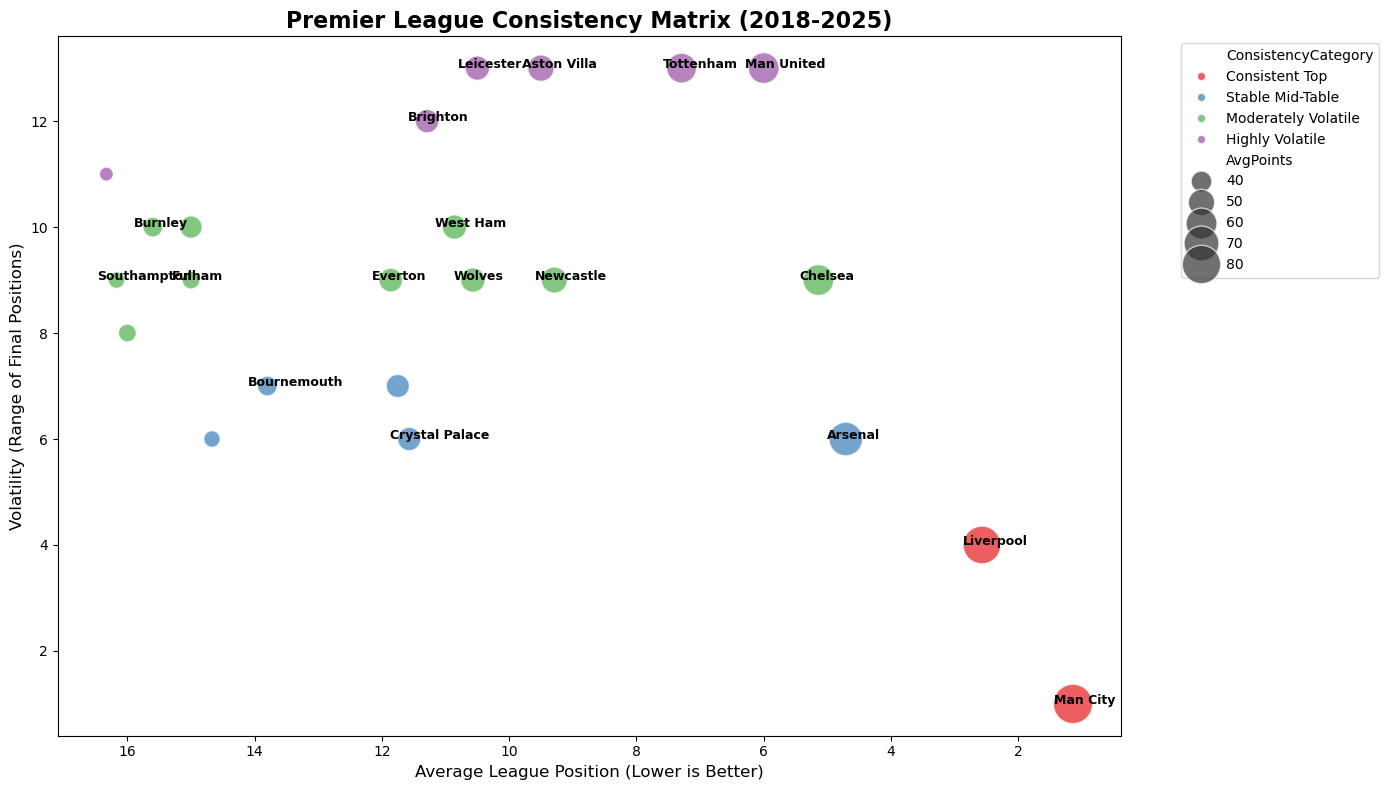

In [7]:
# --- QUESTION 7: The Consistency Matrix ---

# 1. Load the Boss Query data
file_path_7 = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\team_consistency.csv.csv"
df_const = pd.read_csv(file_path_7)

# 2. Set up a large canvas
plt.figure(figsize=(14, 8))

# 3. Create a scatter plot matrix: Average Position vs Volatility (Range)
sns.scatterplot(data=df_const, 
                x='AvgPosition', 
                y='Volatility', 
                hue='ConsistencyCategory', 
                size='AvgPoints', 
                sizes=(100, 800), 
                alpha=0.7, 
                palette='Set1')

# 4. Add team names next to the bubbles
for i in range(df_const.shape[0]):
    # Only label teams that have played 5+ seasons to keep the chart clean
    if df_const['SeasonsPlayed'][i] >= 5:
        plt.text(df_const['AvgPosition'][i] + 0.3, 
                 df_const['Volatility'][i], 
                 df_const['Team'][i], 
                 fontsize=9, fontweight='bold')

# 5. Format the matrix
plt.title('Premier League Consistency Matrix (2018-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Average League Position (Lower is Better)', fontsize=12)
plt.ylabel('Volatility (Range of Final Positions)', fontsize=12)

# Invert X axis so 1st place is on the left side of the chart
plt.gca().invert_xaxis() 

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Render
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3288\4050147355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_upsets_top, x='GoalMargin', y='MatchResult', palette='Reds_r')


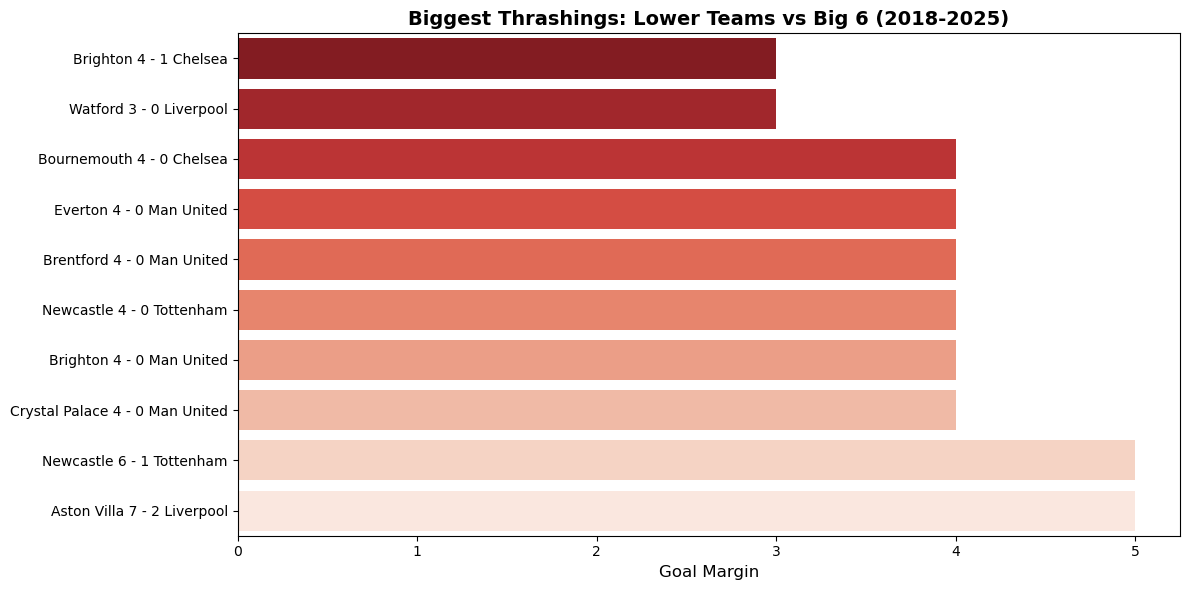

In [8]:
# --- QUESTION 4: Biggest Upsets (Goal Margin) ---

file_4 = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\biggest_upsets.csv.csv"
df_upsets = pd.read_csv(file_4)

# Grab the top 10 worst beatdowns and sort them so the biggest is at the top
df_upsets_top = df_upsets.head(10).sort_values(by='GoalMargin', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_upsets_top, x='GoalMargin', y='MatchResult', palette='Reds_r')

plt.title('Biggest Thrashings: Lower Teams vs Big 6 (2018-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Goal Margin', fontsize=12)
plt.ylabel('') # Removing the y-axis label since the match text explains itself

plt.tight_layout()
plt.show()

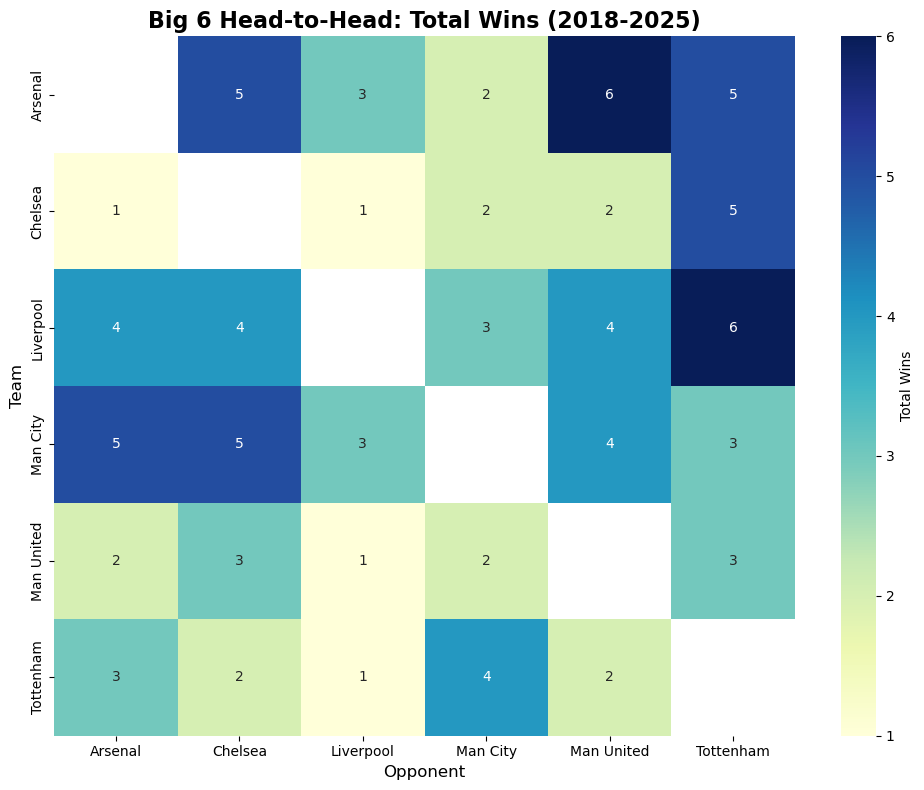

In [9]:
# --- QUESTION 5: Big 6 Rivalry Heatmap ---

file_5 = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\big6_h2h.csv.csv"
df_h2h = pd.read_csv(file_5)

# Pivot the data: Team A on the left, Team B on the bottom, Wins in the middle
h2h_matrix = df_h2h.pivot(index='Team', columns='Opponent', values='Wins')

plt.figure(figsize=(10, 8))
# The 'annot=True' puts the exact number of wins inside the colored boxes
sns.heatmap(h2h_matrix, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Total Wins'})

plt.title('Big 6 Head-to-Head: Total Wins (2018-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Opponent', fontsize=12)
plt.ylabel('Team', fontsize=12)

plt.tight_layout()
plt.show()

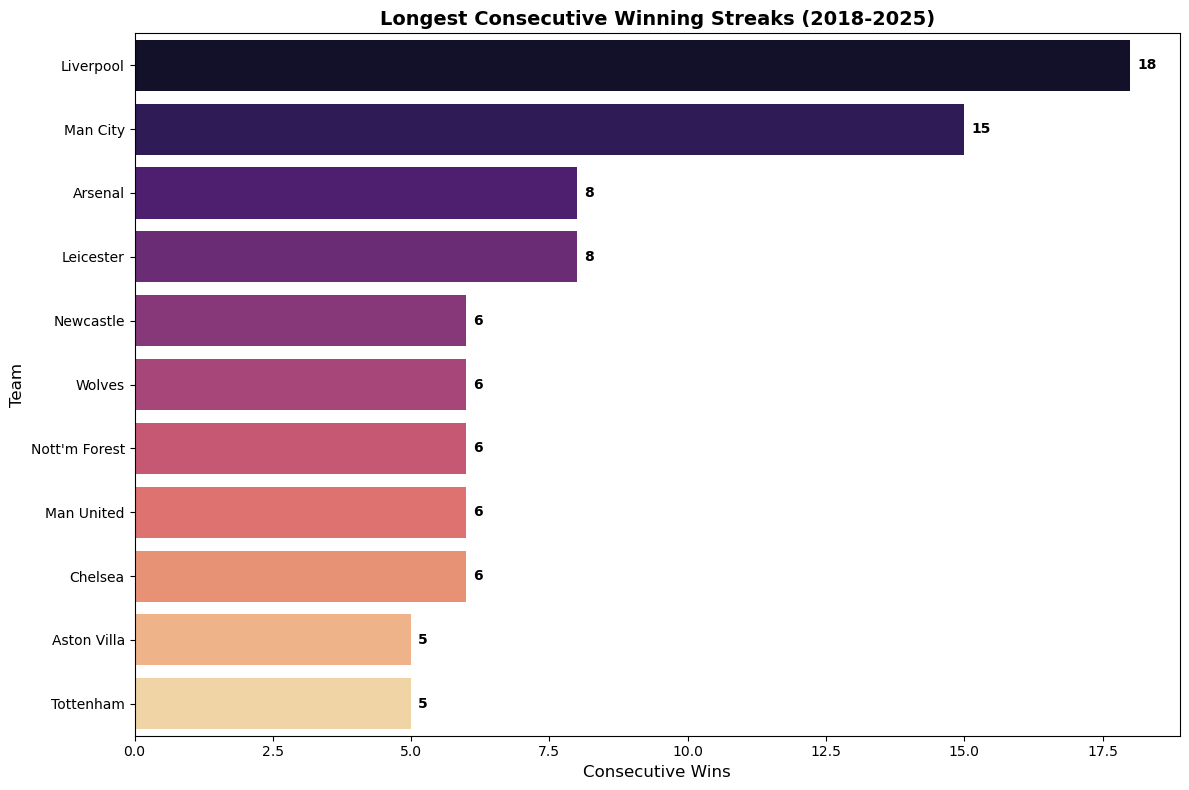

In [13]:
# --- QUESTION 6: Longest Win Streaks ---

file_6 = r"C:\Users\user\Documents\moringa-prep\premier-league-analysis\data\win_streaks.csv.csv"
df_streaks = pd.read_csv(file_6)

# Sort by the longest streak and grab the top 15 teams
df_streaks = df_streaks.sort_values(by='LongestWinStreak', ascending=False).head(15)

plt.figure(figsize=(12, 8))

# Updated to fix the Seaborn FutureWarning
ax = sns.barplot(data=df_streaks, x='LongestWinStreak', y='Team', hue='Team', palette='magma', legend=False)

# Loop through EVERY container so all bars get their label
for container in ax.containers:
    ax.bar_label(container, padding=5, color='black', fontweight='bold')

plt.title('Longest Consecutive Winning Streaks (2018-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Consecutive Wins', fontsize=12)
plt.ylabel('Team', fontsize=12)

plt.tight_layout()
plt.show()